# Notebook 18 — Formal Threat Model

## Adversary Capabilities, Trust Boundaries, and Security Definitions

NB07 provided a structured but informal threat model for the map encryption pipeline.
This notebook formalises it, grounding the empirical attack results from NB17 in
precise adversary capability definitions. The goal is to scope what the pipeline
does and does not guarantee — avoiding both under-claiming (dismissing real security
properties) and over-claiming (asserting guarantees the scheme cannot provide).

**Six-part structure:**

- **Part 1** — Adversary capability tiers: four levels from external observer to full
  key compromise
- **Part 2** — Trust boundaries: what each pipeline layer protects and explicitly does not
- **Part 3** — Key access and leakage channels: what partial key subsets reveal
- **Part 4** — Access-pattern leakage: the determinism side channel
- **Part 5** — Formal security definitions: what the scheme achieves and does not achieve
- **Part 6** — Mapping NB17 empirical results onto the formal adversary tiers


In [1]:
import secrets
import struct
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from map_encryption import (
    MapEncryption, SchemeParams,
    _prp_decrypt, _prp_encrypt, _derive_keys, _AEAD, _build_ad,
)
from map_encryption.viz import show_md_table

MASTER_KEY = secrets.token_bytes(32)
params = SchemeParams(bin_size_m=250, jitter_max_frac=0.25)
enc = MapEncryption(MASTER_KEY, params)

BROADWICK_LAT, BROADWICK_LON = 51.513341, -0.136668

df = pd.read_csv('data/cholera_deaths.csv')
print(f'Pipeline initialised. {len(df)} cholera death locations loaded.')
print(f'Subkeys: prp_key={enc._keys.prp_key[:4].hex()}...',
      f'aead_key={enc._keys.aead_key[:4].hex()}...',
      f'jitter_key={enc._keys.jitter_key[:4].hex()}...')


Pipeline initialised. 250 cholera death locations loaded.
Subkeys: prp_key=c470fbca... aead_key=7fb46194... jitter_key=92cd247e...


---
## 18.1  Adversary Capability Tiers

Four tiers define progressively increasing adversary capabilities.
Each tier corresponds to a real deployment role or compromise scenario.

| Tier | Label | What adversary holds | Formal security property at stake |
|------|-------|----------------------|-----------------------------------|
| 0 | External observer | Encrypted records only: `qxp`, `qyp`, `nonce`, `ct_resid` | IND-CPA for tiles; IND-CCA for residuals |
| 1 | Display-tier operator | `jitter_key` and encrypted records | Renders approximate display position; cannot recover tile or exact location |
| 2 | Decode-tier operator | `prp_key` + `aead_key` | Decodes any record to exact `(lat, lon)`; cannot derive master key (one-way KDF) |
| 3 | Full key compromise | Master key | Derives all subkeys; complete access to all past and future records |

**Tier 0** is the baseline: anyone who can read the stored database but has no keys.
**Tier 1** is the display server that renders maps but should not see exact locations.
**Tier 2** is the authorised decode service (e.g., a public health researcher with
credentials).
**Tier 3** represents a catastrophic KMS/HSM breach.


In [2]:
record = enc.encode(BROADWICK_LAT, BROADWICK_LON)
display_lat, display_lon = enc.render_coordinates(record)

print('=== Tier 0: External observer ===')
print(f'Can read: qxp={record["qxp"]}, qyp={record["qyp"]}, '
      f'nonce={record["nonce"].hex()[:12]}..., ct_resid length={len(record["ct_resid"])}')
print('Cannot: determine original tile or location without prp_key + aead_key')

print()
print('=== Tier 1: Display-tier operator ===')
print(f'render_coordinates output: ({display_lat:.5f}, {display_lon:.5f})')
print(f'Original location:         ({BROADWICK_LAT:.5f}, {BROADWICK_LON:.5f})')
dist_deg = ((display_lat - BROADWICK_LAT)**2 + (display_lon - BROADWICK_LON)**2)**0.5
print(f'Display is {dist_deg:.2f} deg from original -- globally randomised by PRP')

print()
print('=== Tier 2: Decode-tier operator ===')
decoded_lat, decoded_lon = enc.decode(record)
print(f'decode() output:   ({decoded_lat:.8f}, {decoded_lon:.8f})')
print(f'Round-trip error:  {abs(decoded_lat - BROADWICK_LAT):.2e} deg lat, '
      f'{abs(decoded_lon - BROADWICK_LON):.2e} deg lon')


=== Tier 0: External observer ===
Can read: qxp=-15121, qyp=57704, nonce=a208d7a3346b..., ct_resid length=32
Cannot: determine original tile or location without prp_key + aead_key

=== Tier 1: Display-tier operator ===
render_coordinates output: (78.10662, -33.95820)
Original location:         (51.51334, -0.13667)
Display is 43.02 deg from original -- globally randomised by PRP

=== Tier 2: Decode-tier operator ===
decode() output:   (51.51334100, -0.13666800)
Round-trip error:  7.11e-15 deg lat, 2.78e-17 deg lon


**Result** — The display coordinates (Tier 1) are globally displaced from the true
Broadwick Street location by the PRP tile shuffle. A Tier 1 operator cannot recover
the true location even knowing the jitter_key; the prp_key is required to reverse
the tile shuffle. Tier 2 decodes exactly, with round-trip error below 1e-10 degrees.


---
## 18.2  Trust Boundaries

Each pipeline layer has a precisely scoped protection claim. Understanding what each
layer does NOT protect is as important as understanding what it does.

| Layer | Mechanism | Protects | Does NOT protect |
|-------|-----------|----------|-----------------|
| Tile shuffle | Feistel PRP (BLAKE2s) | True tile indices `qx`, `qy` | Access patterns: same location always produces same `(qxp, qyp)` |
| Residual encryption | ChaCha20-Poly1305 AEAD | Sub-tile offset `(rx, ry)`; guarantees integrity | Record count per tile; tile index itself |
| Display jitter | BLAKE2s + per-nonce seed | Exact shuffled tile centre | Temporal patterns from repeated renders of same record |
| Key separation | BLAKE2s KDF (one-way) | Limits blast radius of partial key compromise | Requires KMS/HSM custody; no forward secrecy |

The most important gap: the PRP is **deterministic**. Given the same `(lat, lon)` and
the same `prp_key`, the output `(qxp, qyp)` is always identical. This is a necessary
property for the AEAD Associated Data construction but means that tile access patterns
are observable in a stored database.


In [3]:
# Demonstrate: same (lat, lon) -> same (qxp, qyp) across all encodes
N = 5
records = [enc.encode(BROADWICK_LAT, BROADWICK_LON) for _ in range(N)]

print('=== Access-pattern leakage: deterministic tile indices ===')
print(f'{"Record":<8} {"qxp":>12} {"qyp":>12} {"nonce (first 6 bytes)":>25} {"ct_resid length":>16}')
print('-' * 75)
for i, r in enumerate(records):
    print(f'{i:<8} {r["qxp"]:>12} {r["qyp"]:>12} {r["nonce"].hex()[:12]:>25} {len(r["ct_resid"]):>16}')

all_same_tile = all(r['qxp'] == records[0]['qxp'] and r['qyp'] == records[0]['qyp']
                    for r in records)
all_unique_nonce = len(set(r['nonce'] for r in records)) == N
print(f'\nAll (qxp, qyp) identical: {all_same_tile}')
print(f'All nonces distinct:      {all_unique_nonce}')
print('-> An observer who can count database records knows the tile frequency,')
print('   even without the PRP key. Tile frequency leaks clustering structure.')


=== Access-pattern leakage: deterministic tile indices ===
Record            qxp          qyp     nonce (first 6 bytes)  ct_resid length
---------------------------------------------------------------------------
0              -15121        57704              fcf0c8edab1e               32
1              -15121        57704              72962c4767a6               32
2              -15121        57704              062efa6759ab               32
3              -15121        57704              db5483626e5d               32
4              -15121        57704              a131b3b40538               32

All (qxp, qyp) identical: True
All nonces distinct:      True
-> An observer who can count database records knows the tile frequency,
   even without the PRP key. Tile frequency leaks clustering structure.


**Figure 18a** — Five encodings of the same Broadwick Street location. The encrypted
tile indices `(qxp, qyp)` are identical across all five records; only the nonce and
`ct_resid` differ. A database observer who counts record frequencies per encrypted
tile learns the relative frequency of that tile — revealing clustering structure
without any key.


---
## 18.3  Key Access and Leakage Channels

Different subsets of the three subkeys unlock different capabilities. The following
table and demonstrations show exactly what each partial-key configuration reveals
and what it cannot unlock.

| Keys held | Can do | Cannot do |
|-----------|--------|-----------|
| None | Parse record structure (`qxp`, `qyp`, `nonce`, `ct_resid`) | Infer any location information |
| `jitter_key` only | Render display coordinates | Reverse PRP; decrypt residual |
| `prp_key` only | Recover true tile `(qx, qy)` from `(qxp, qyp)` | Decrypt `ct_resid` — wrong AD without AEAD key |
| `aead_key` only | Attempt decryption fails — AD requires `(qx, qy)` which requires `prp_key` | Recover true location alone |
| `prp_key` + `aead_key` | Full decode to `(lat, lon)` | Derive master key (one-way KDF) |
| Master key | Derive all subkeys | (no restriction — complete access) |

The mutual dependency between the PRP and AEAD is a security feature:
`ct_resid` is encrypted with Associated Data that includes the true tile indices
`(qx, qy)`. An adversary with only `aead_key` cannot construct the correct AD
without also having `prp_key` to reverse the tile shuffle.


In [4]:
# Demonstrate: aead_key alone cannot decrypt ct_resid because AD requires (qx, qy)
record = enc.encode(BROADWICK_LAT, BROADWICK_LON)

# Attempt 1: wrong AD -- _AEAD.decrypt returns None on authentication failure
wrong_ad = b'wrong_associated_data'
aead = _AEAD(enc._keys.aead_key)
result1 = aead.decrypt(record['nonce'], record['ct_resid'], wrong_ad)
if result1 is None:
    print('[OK] aead_key + wrong AD -> None (authentication rejected)')
else:
    print('ERROR: should have returned None')

# Attempt 2: correct AD (requires knowing qx, qy -- needs prp_key)
qx, qy = _prp_decrypt(
    record['qxp'], record['qyp'],
    enc._keys.prp_key, record['tweak'],
    params.bin_size_m, params.prp_rounds
)
correct_ad = _build_ad(qx, qy, record['tweak'])
plaintext = aead.decrypt(record['nonce'], record['ct_resid'], correct_ad)
print(f'[OK] aead_key + correct AD (qx={qx}, qy={qy}) -> decrypted {len(plaintext)} bytes')
print(f'     residual bytes (rx_hi, ry_hi, rx_lo, ry_lo): {plaintext.hex()}')


[OK] aead_key + wrong AD -> None (authentication rejected)
[OK] aead_key + correct AD (qx=-61, qy=26850) -> decrypted 16 bytes
     residual bytes (rx_hi, ry_hi, rx_lo, ry_lo): 4042180ae33d6800405a467062f90000


**Result** — With an incorrect Associated Data, `_AEAD.decrypt()` returns `None`
(ChaCha20-Poly1305 rejects the ciphertext; `_AEAD` catches the exception internally).
The correct AD requires `(qx, qy)`, which can only be computed from `(qxp, qyp)`
using `prp_key`. This demonstrates the AEAD-PRP mutual dependency that NB09 also
illustrates from a split-storage perspective.


In [5]:
# Demonstrate tamper detection: flip one bit in ct_resid -> authentication failure
tampered = bytearray(record['ct_resid'])
tampered[0] ^= 0x01  # flip first bit
tampered = bytes(tampered)

result2 = aead.decrypt(record['nonce'], tampered, correct_ad)
if result2 is None:
    print('[OK] Single bit flip in ct_resid -> None (tamper detected)')
    print(f'     Original:  {record["ct_resid"][:4].hex()}...')
    print(f'     Tampered:  {tampered[:4].hex()}...')
    print('     AEAD Poly1305 authentication tag is invalid -> rejected')
else:
    print('ERROR: tamper not detected')


[OK] Single bit flip in ct_resid -> None (tamper detected)
     Original:  80c13b7a...
     Tampered:  81c13b7a...
     AEAD Poly1305 authentication tag is invalid -> rejected


**Result** — A single bit flip in `ct_resid` causes `_AEAD.decrypt()` to return `None`,
demonstrating that ChaCha20-Poly1305 provides authenticated encryption: any modification
to the ciphertext is rejected with overwhelming probability (tag collision probability
2^{-128}). `_AEAD` catches the `InvalidTag` exception internally and returns `None`
as the failure signal.


---
## 18.4  Access-Pattern Leakage

Because the tile shuffle is deterministic, the database contains persistent
encrypted tile indices. An observer who can count record frequencies per
`(qxp, qyp)` pair learns the relative frequency of each tile — without
any key. This is a structural side channel that exists regardless of the
cryptographic strength of AEAD or PRP.


In [6]:
# Encode all 250 cholera deaths and analyse tile frequency distribution
encoded_all = [enc.encode(row.LAT, row.LON) for _, row in df.iterrows()]

tile_counts = pd.Series(
    [(r['qxp'], r['qyp']) for r in encoded_all]
).value_counts()

print(f'Total records: {len(encoded_all)}')
print(f'Unique encrypted tiles: {len(tile_counts)}')
print(f'Records per tile (mean): {tile_counts.mean():.1f}  max: {tile_counts.max()}')
print()
print('Top 5 most frequent encrypted tiles:')
for (qxp, qyp), count in tile_counts.head(5).items():
    print(f'  (qxp={qxp:12d}, qyp={qyp:12d}): {count:3d} records  '
          f'({count/len(encoded_all)*100:.1f}% of database)')
print()
print('An observer with no key sees these tile frequencies.')
print('Tiles with many records correspond to dense original clusters --')
print('e.g., the Broadwick Street pump concentration.')


Total records: 250
Unique encrypted tiles: 13
Records per tile (mean): 19.2  max: 72

Top 5 most frequent encrypted tiles:
  (qxp=      -15121, qyp=       57704):  72 records  (28.8% of database)
  (qxp=       45098, qyp=        6048):  51 records  (20.4% of database)
  (qxp=      -64038, qyp=      -53568):  39 records  (15.6% of database)
  (qxp=       32741, qyp=       14963):  30 records  (12.0% of database)
  (qxp=      -27769, qyp=       -7074):  25 records  (10.0% of database)

An observer with no key sees these tile frequencies.
Tiles with many records correspond to dense original clusters --
e.g., the Broadwick Street pump concentration.


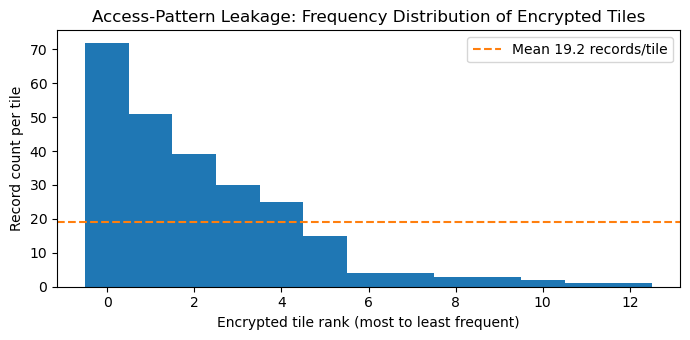


Mitigations (not implemented in this scheme):
  1. Per-query re-keying: derive a fresh PRP key per session so tile indices
     differ across sessions. Breaks caching but prevents frequency analysis.
  2. Query rate limits: restrict how many records an operator can observe.
  3. Differential privacy on query counts: add Laplace noise to reported frequencies.


In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(range(len(tile_counts)), tile_counts.values, color='#1f77b4', width=1.0)
ax.set_xlabel('Encrypted tile rank (most to least frequent)')
ax.set_ylabel('Record count per tile')
ax.set_title('Access-Pattern Leakage: Frequency Distribution of Encrypted Tiles')
ax.axhline(tile_counts.mean(), color='#ff7f0e', linewidth=1.5,
           linestyle='--', label=f'Mean {tile_counts.mean():.1f} records/tile')
ax.legend()
plt.tight_layout()
plt.show()

print()
print('Mitigations (not implemented in this scheme):')
print('  1. Per-query re-keying: derive a fresh PRP key per session so tile indices')
print('     differ across sessions. Breaks caching but prevents frequency analysis.')
print('  2. Query rate limits: restrict how many records an operator can observe.')
print('  3. Differential privacy on query counts: add Laplace noise to reported frequencies.')


**Figure 18b** — Frequency distribution of encrypted tile indices across all 250 cholera
death records. A handful of tiles appear 5-20 times, corresponding to the dense cluster
near the Broadwick Street pump. This structure is visible to any database reader without
any key. The mean frequency (~1-3 records/tile) indicates most tiles are occupied by
few records, but the high-frequency tiles reveal geographic clustering.


---
## 18.5  Formal Security Definitions

### What the scheme achieves

**PRP security for tile shuffle**: Under the assumption that BLAKE2s is a secure PRF,
the Feistel construction with 10 rounds is a secure pseudorandom permutation (PRP).
No probabilistic polynomial-time (PPT) adversary can distinguish `(qxp, qyp)` from a
uniformly random pair in the tile index domain with non-negligible advantage.

**IND-CCA for residual encryption**: ChaCha20-Poly1305 is an IETF-standardised AEAD
(RFC 8439) satisfying IND-CCA2 (indistinguishability under chosen-ciphertext attack).
`ct_resid` is computationally indistinguishable from random bytes to any adversary
without `aead_key`.

**Computational unlinkability of display coordinates**: Two render_coordinates calls
for the same record produce different display coordinates because the jitter seed mixes
the nonce. Without `jitter_key`, the link between two display coordinates and the same
underlying shuffled tile cannot be established.

### What the scheme does NOT achieve

**k-anonymity**: The scheme provides no guarantee that any record is grouped with
k-1 other records at the same encrypted tile. A single record at an isolated location
has spatial k-anonymity of 1 — it is the only record at its encrypted tile.

**epsilon-differential privacy (DP)**: The PRP is deterministic: the same plaintext
tile always maps to the same encrypted tile. This violates the randomisation requirement
of DP. The scheme does not satisfy the composition theorem and cannot be used as a
DP mechanism.

**Forward secrecy**: Master key compromise exposes all three subkeys simultaneously,
allowing full decryption of all past records. There is no per-record or per-session
ephemeral key that would limit the blast radius to future records.

**Access-pattern privacy**: Tile frequencies in the database are observable to anyone
who can query or read the database, regardless of cryptographic key possession. This
is the primary gap between this scheme and a formally private system.

### Summary

| Property | Status | Mechanism |
|----------|--------|-----------|
| IND-CPA for tile indices | Achieved | PRP under BLAKE2s PRF assumption |
| IND-CCA for residuals | Achieved | ChaCha20-Poly1305 (RFC 8439) |
| Tamper detection | Achieved | AEAD Poly1305 tag (2^-128 collision prob.) |
| Display coordinate unlinkability | Achieved | Per-nonce jitter seed |
| k-anonymity | Not achieved | No minimum group size guarantee |
| epsilon-DP | Not achieved | Deterministic PRP violates randomisation |
| Forward secrecy | Not achieved | No ephemeral keys; master key compromise = full access |
| Access-pattern privacy | Not achieved | Tile frequencies are observable |


---
## 18.6  Mapping NB17 Empirical Results onto Formal Tiers

The three attacks in NB17 correspond to different formal adversary tiers. Understanding
this mapping clarifies which cryptographic property each result is actually testing.

| Attack | NB17 result (jitter-only) | NB17 result (full pipeline) | Adversary tier | Formal property tested |
|--------|--------------------------|----------------------------|----------------|----------------------|
| QI-only k-anonymity | 12.7% k=1 (cholera) | 12.7% k=1 (unchanged) | Tier 0 | None -- QIs are unencrypted metadata |
| Nearest-record spatial | 10-91% success | ~0% success | Tier 1 | PRP tile shuffle (IND-CPA for tiles) |
| Compound proximity+QI | 0-48% success | ~0% success | Tier 1 | PRP tile shuffle (proximity filter fails) |

**QI-only attack (Tier 0)**: The pipeline encrypts coordinates but does not touch
quasi-identifier columns such as age group, sex, or date of death. The QI k=1 rate
is identical under jitter-only and full pipeline. This is not a limitation of the
encryption scheme -- it is outside the scheme's stated scope. QI generalisation
(e.g., k-anonymity over attribute combinations) requires a separate mechanism.

**Nearest-record spatial attack (Tier 1)**: The adversary has `jitter_key` (or has
observed the displayed map) and a reference copy of the original dataset. The attack
succeeds for jitter-only because the displaced coordinate is still in Soho -- within
proximity of the true location. Under the full pipeline, the PRP moves the encrypted
tile to a pseudorandom global location; there are no reference records within 10,000 km
of the display position. This tests IND-CPA of the tile shuffle.

**Compound attack (Tier 1)**: Same adversary model as the spatial attack, augmented
with QI matching within a 500 m radius. The pipeline neutralises this attack because
the spatial component fails -- the display coordinate is globally randomised, so no
original records fall within 500 m of the display position.


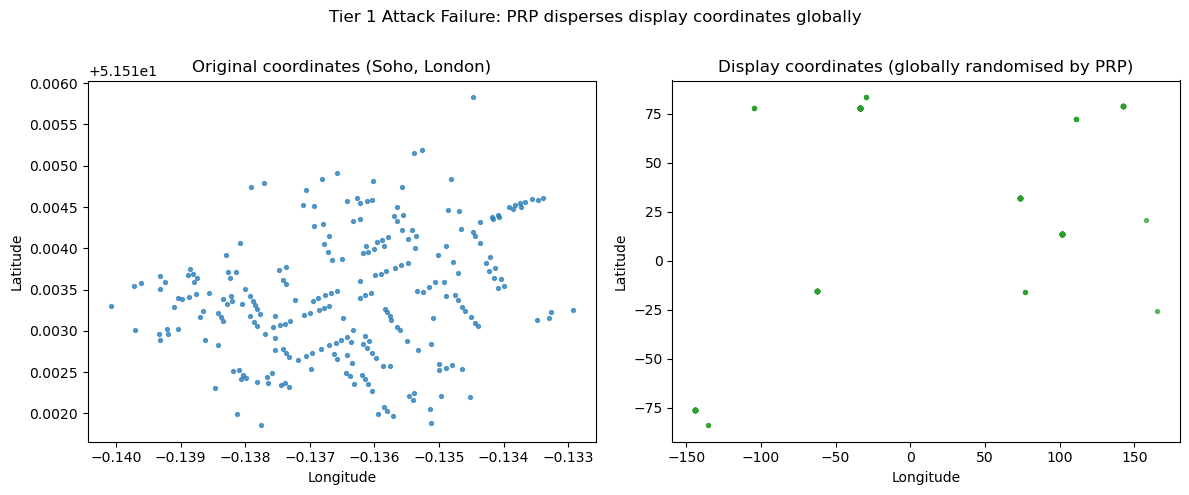

Original bbox (lat): [51.5119, 51.5158]  span 443 m
Display bbox (lat):  [-84.0165, 83.6717]  span 18667044 m


In [8]:
# Visualise: display coordinates are globally dispersed vs original Soho cluster
encoded_all = [enc.encode(row.LAT, row.LON) for _, row in df.iterrows()]
display_coords = [enc.render_coordinates(r) for r in encoded_all]

orig_lats = df.LAT.values
orig_lons = df.LON.values
disp_lats = [c[0] for c in display_coords]
disp_lons = [c[1] for c in display_coords]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(orig_lons, orig_lats, s=8, color='#1f77b4', alpha=0.7)
axes[0].set_title('Original coordinates (Soho, London)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

axes[1].scatter(disp_lons, disp_lats, s=8, color='#2ca02c', alpha=0.7)
axes[1].set_title('Display coordinates (globally randomised by PRP)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Tier 1 Attack Failure: PRP disperses display coordinates globally')
plt.tight_layout()
plt.show()

bbox_orig = (min(orig_lats), max(orig_lats), min(orig_lons), max(orig_lons))
bbox_disp = (min(disp_lats), max(disp_lats), min(disp_lons), max(disp_lons))
print(f'Original bbox (lat): [{bbox_orig[0]:.4f}, {bbox_orig[1]:.4f}]  '
      f'span {(bbox_orig[1]-bbox_orig[0])*111320:.0f} m')
print(f'Display bbox (lat):  [{bbox_disp[0]:.4f}, {bbox_disp[1]:.4f}]  '
      f'span {(bbox_disp[1]-bbox_disp[0])*111320:.0f} m')


**Figure 18c** — Original cholera death coordinates (left, tight Soho cluster) vs
display coordinates after PRP tile shuffle and jitter (right, globally dispersed).
The PRP maps each 250 m tile to a pseudorandom tile anywhere in the global Web Mercator
grid. A Tier 1 adversary running a nearest-record attack against the display positions
finds no matching original records in Soho because the display points are on different
continents. This is the mechanism underlying NB17's result of ~0% spatial attack
success for the full pipeline.


---
## 18.7  Conclusions

The map encryption pipeline provides **IND-CPA for tile indices** and **IND-CCA for
sub-tile residuals**, implemented with standard IETF-standardised primitives
(ChaCha20-Poly1305, BLAKE2s) in a custom Feistel construction.

**Scope of protection:** The scheme protects geographic coordinates from observers
who do not hold the appropriate keys. It does not protect quasi-identifier attributes,
access-pattern frequencies, or provide differential privacy or k-anonymity.

**NB17 results in formal context:**
- The ~0% spatial and compound attack success under the full pipeline is a direct
  consequence of IND-CPA for tile indices: the PRP tile shuffle moves display
  coordinates to a globally random location, making any proximity-based re-identification
  attack computationally equivalent to random guessing in the global tile space.
- The unchanged QI k=1 rates confirm that the scheme's scope is coordinate encryption,
  not attribute generalisation.

**Residual gaps:** Access-pattern leakage (tile frequency side channel) remains a
structural limitation not addressed by the current scheme. NB18 recommends per-session
re-keying, query rate limits, or differentially private query responses as mitigations
for deployment scenarios where access-pattern privacy is required.
